In [38]:
import numpy as np
import matplotlib.pyplot as plt
import math
import os
import scipy
import pathlib

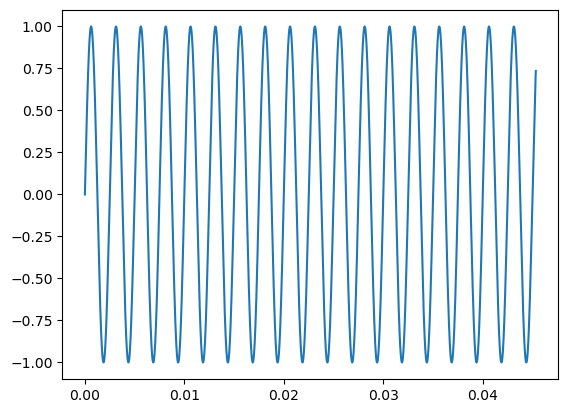

In [ ]:
DUR = 3
SR = 44100
FREQ = 400
t = np.linspace(0, DUR, int(SR) * DUR, endpoint=False)
sig = np.sin(2 * np.pi * FREQ * t)
plt.plot(t[0 : FREQ * 5], sig[0 : FREQ * 5])

### Plot sine wave

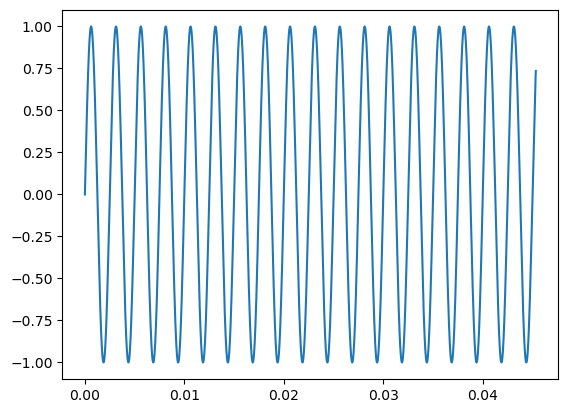

In [40]:
DUR = 3
SR = 44100
FREQ = 400
t = np.linspace(0, DUR, int(SR) * DUR, endpoint=False)
sig = np.sin(2 * np.pi * FREQ * t)
plt.plot(t[0 : FREQ * 5], sig[0 : FREQ * 5])

### Write to file

[400, 503.96841995794927, 599.3228307506727]


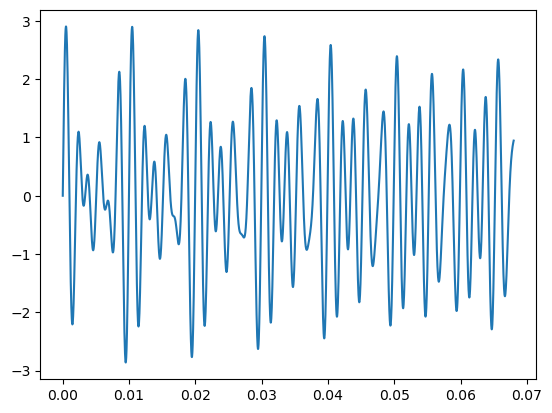

In [41]:
DUR = 3
SR = 44100
BASE = 400
FREQS = [BASE, BASE * 2 ** (4 / 12), BASE * 2 ** (7 / 12)]
print(FREQS)
WAV_ABSPATH = (
    pathlib.Path(os.environ.get("ARTIFACTS_ABSPATH", ""))
    / "sine-400-minor-triad.wav"
)

t = np.linspace(0, DUR, int(SR) * DUR, endpoint=False)
sig = []
for freq in FREQS:
    sig.append(np.sin(2 * np.pi * freq * t))

sig = np.sum(sig, axis=0)

plot_length = math.ceil(max(FREQS)) * 5
plt.plot(t[0:plot_length], sig[0:plot_length])
sig_max = np.max(np.abs(sig))
sig = sig / sig_max

pcm = np.int16(sig * (2**15 - 1))
scipy.io.wavfile.write(WAV_ABSPATH, SR, pcm)

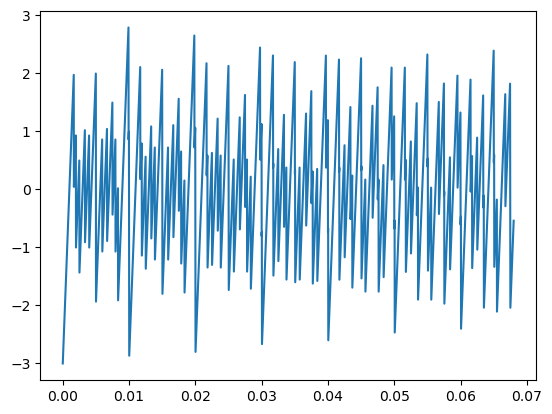

In [49]:
DUR = 3
SR = 44100
BASE = 400
FREQS = [BASE, BASE * 2 ** (4 / 12), BASE * 2 ** (7 / 12)]
WAVEFORM = "sawtooth"  # or other scipy.signal methods
WAVEFORM_ARGS = {}

WAV_ABSPATH = (
    pathlib.Path(os.environ.get("ARTIFACTS_ABSPATH", ""))
    / f"{WAVEFORM}-400-minor-triad.wav"
)

t = np.linspace(0, DUR, int(SR) * DUR, endpoint=False)
sig = []
method = getattr(scipy.signal, WAVEFORM)
for freq in FREQS:
    sig.append(method(2 * np.pi * freq * t, **WAVEFORM_ARGS))

sig = np.sum(sig, axis=0)

plot_length = math.ceil(max(FREQS)) * 5
plt.plot(t[0:plot_length], sig[0:plot_length])
sig_max = np.max(np.abs(sig))
sig = sig / sig_max

pcm = np.int16(sig * (2**15 - 1))
scipy.io.wavfile.write(WAV_ABSPATH, SR, pcm)